# ESE 02

## Samples n>1

In [22]:
import qdatoolkit as qda
import pandas as pd
import numpy as np

# First dataset (n=5)
gears = pd.DataFrame({
    'x1': [23.92, 23.89, 23.94, 23.89, 24.35, 23.44, 24.16, 23.95, 23.98, 23.81, 24.08, 23.76, 24.26, 23.87, 24.34, 24.00, 24.45, 23.66, 24.10, 24.19],
    'x2': [24.58, 24.21, 24.11, 24.43, 24.16, 23.97, 24.06, 24.05, 24.21, 23.82, 24.16, 23.78, 24.35, 23.97, 24.24, 24.10, 24.21, 23.78, 23.86, 23.73],
    'x3': [23.84, 23.82, 24.05, 23.97, 23.78, 24.30, 24.21, 23.82, 23.76, 23.97, 23.95, 23.84, 24.13, 23.76, 24.08, 24.03, 23.65, 23.90, 24.00, 24.22],
    'x4': [23.94, 24.06, 23.89, 24.00, 24.47, 24.05, 23.97, 24.08, 24.24, 23.58, 24.38, 24.26, 23.92, 23.97, 24.11, 24.21, 23.90, 24.03, 23.50, 23.70],
    'x5': [23.94, 24.16, 24.10, 24.16, 24.92, 24.24, 24.22, 24.02, 24.13, 24.22, 24.21, 23.90, 23.89, 24.27, 23.98, 24.14, 23.73, 24.06, 24.08, 23.78]
})
data = gears

Normality and Independence

Stack data (if n>1) -> use this to check normality

Runs test statistic = -0.398
Runs test p-value = 0.691



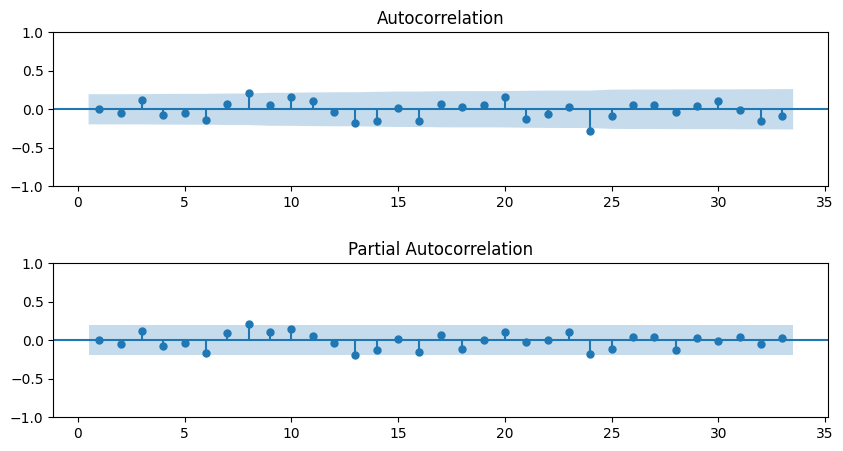

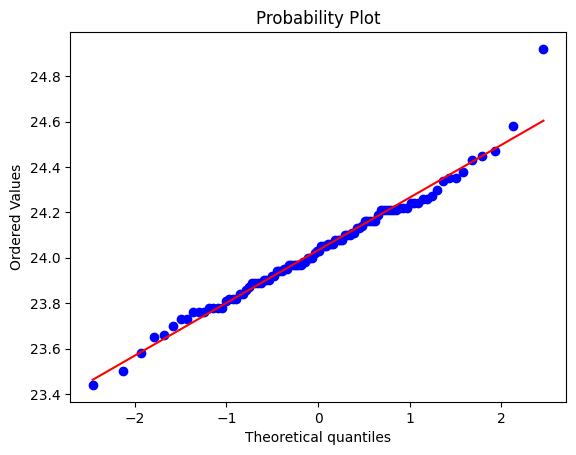

Shapiro-wilk test statistic = 0.981
Shapiro-wilk test p-value = 0.151


In [20]:
# Stack the data into a single column
phase_1_stack = data.stack()

runs_statistic, runs_pvalue = qda.Assumptions(phase_1_stack).independence()
# high p-value => data are independent

sw_statistic, sw_pvalue = qda.Assumptions(phase_1_stack).normality()
# Shapiro-wilk. high p-value => data are normal

Control charts

### Xbar-R

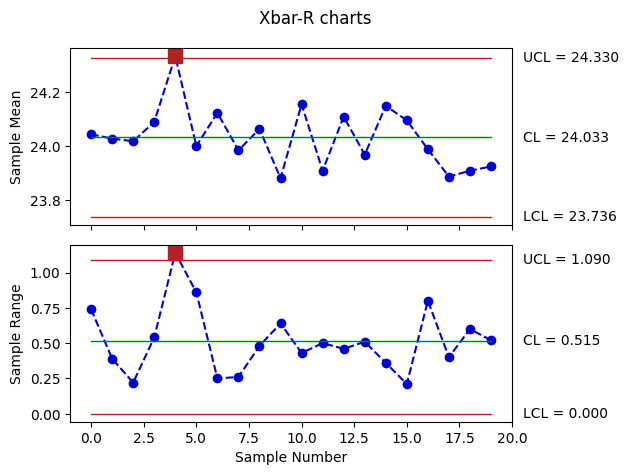

In [11]:
XR = qda.ControlCharts.XbarR(gears)

How to remove an OOC:

In [16]:
# Let's find the array of indexes corresponding to OOC points (one in this case)

# Find the index of the I_TEST1 column different from NaN
OOC_idx = np.where(XR['Xbar_TEST1'].notnull())[0]
# Print the index of the OOC points
print('The index of the OOC point is: {}'.format(OOC_idx))

The index of the OOC point is: [4]


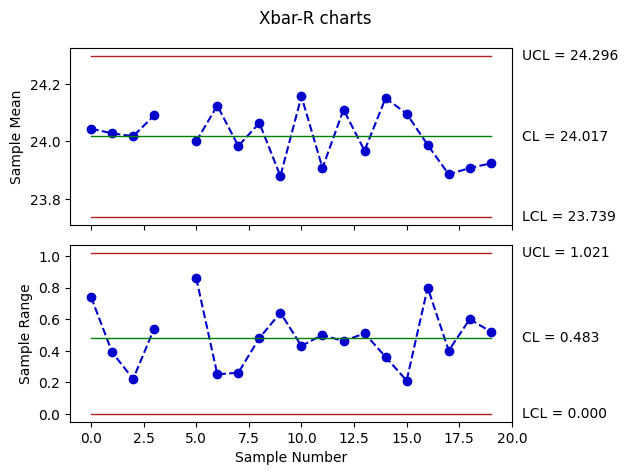

In [19]:
# make a copy of the data
phase_1_cleaned = gears.copy()
# replace the OOC point with NaN
phase_1_cleaned.iloc[OOC_idx] = np.nan
XR = qda.ControlCharts.XbarR(phase_1_cleaned)

### Xbar-S

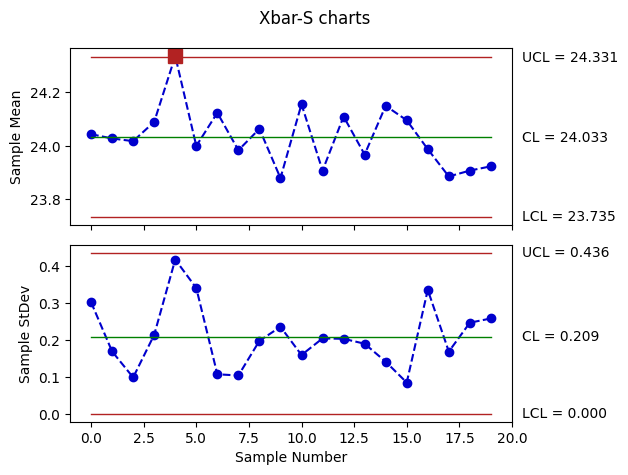

In [21]:
XS = qda.ControlCharts.XbarS(gears)

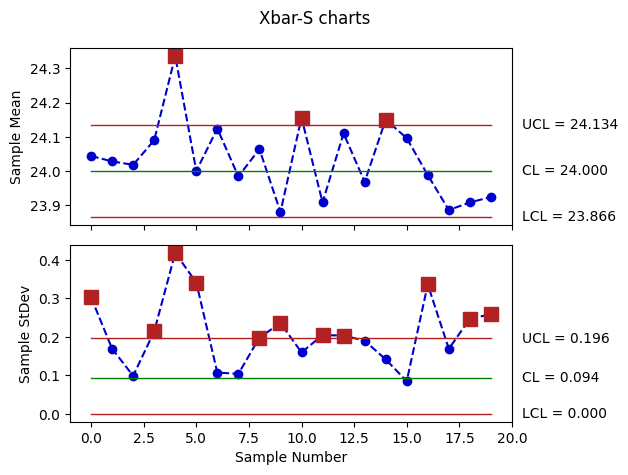

In [27]:
mu = 24
sigma = .1
XS = qda.ControlCharts.XbarS(gears, K = 3, mean=mu, sigma=sigma)

## Individual Samples (n=1)

In [28]:
data = pd.DataFrame({'col_name': [26.56401316698107, 26.80188495061767, 22.102584748305844, 37.580698725514814, 30.5170516969393]})

Runs test statistic = -1.528
Runs test p-value = 0.127



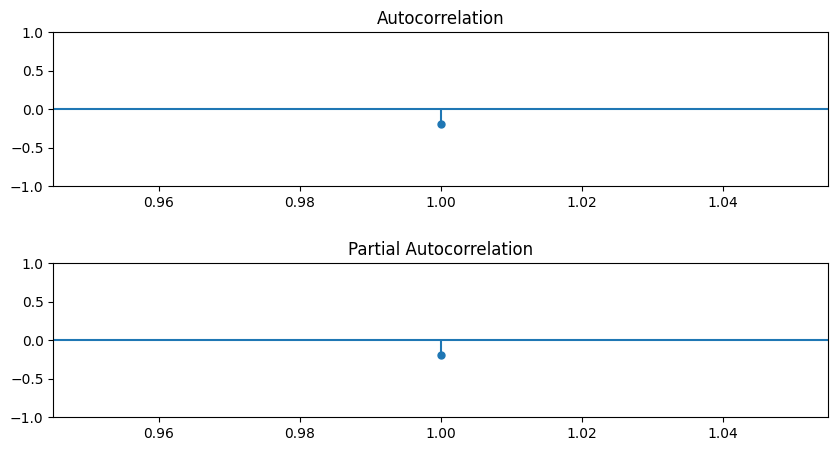

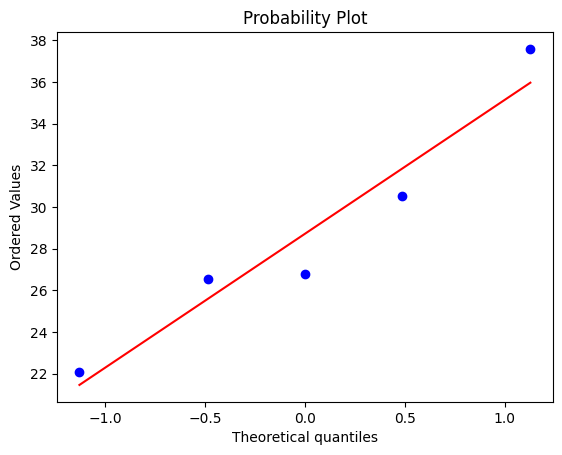

Shapiro-wilk test statistic = 0.944
Shapiro-wilk test p-value = 0.695


In [8]:
runs_statistic, runs_pvalue = qda.Assumptions(data['col_name']).independence()
# high p-value => data are independent

sw_statistic, sw_pvalue = qda.Assumptions(data['col_name']).normality()
# Shapiro-wilk. high p-value => data are normal

### I-MR

In [ ]:
data_IMR = qda.ControlCharts.IMR(data, 'col_name')
# use alpha = 0.01
alpha = 0.01
K_alpha = stats.norm.ppf(1-alpha/2)
IMR = qda.ControlCharts.I(data, 'col_name', K = K_alpha)

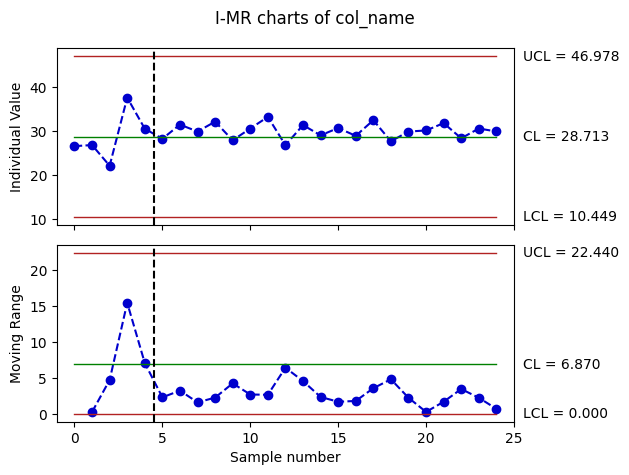

In [30]:
data_phase2 = pd.DataFrame({'col_name': [28.234, 31.456, 29.876, 32.123, 27.890, 30.567, 33.210, 26.789, 31.345, 29.012, 30.678, 28.901, 32.456, 27.654, 29.876, 30.123, 31.789, 28.345, 30.567, 29.890]})
data_all = pd.concat([data, data_phase2], ignore_index=True)
# use only phase 1 to compute CC and plot also phase 2 
new_data_IMR = qda.ControlCharts.IMR(data_all, 'col_name', subset_size=len(data))

Poi ha fatto anche probabilistic CC, ma dipende dalla dist della variabile (nell'esempio era MR half normal)

# ESE 03

In [33]:
import pandas as pd
data = pd.DataFrame({
    'X': [10.45, 10.55, 10.37, 10.64, 10.95, 10.08, 10.50, 10.87, 11.25, 11.46,
          11.39, 11.69, 11.51, 11.28, 11.38, 11.25, 11.63, 11.88, 11.46, 11.67]
})

## I-chart with known σ

This data represent the mean values of a quantity measured in samples of size $ n = 5 $ taken from a population with $ \sigma = 1 $. 

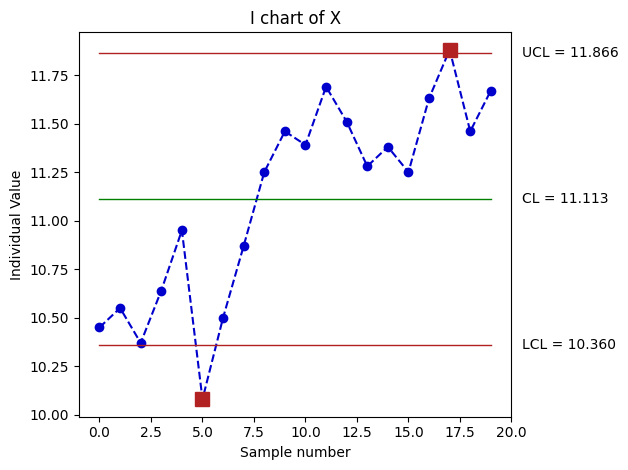

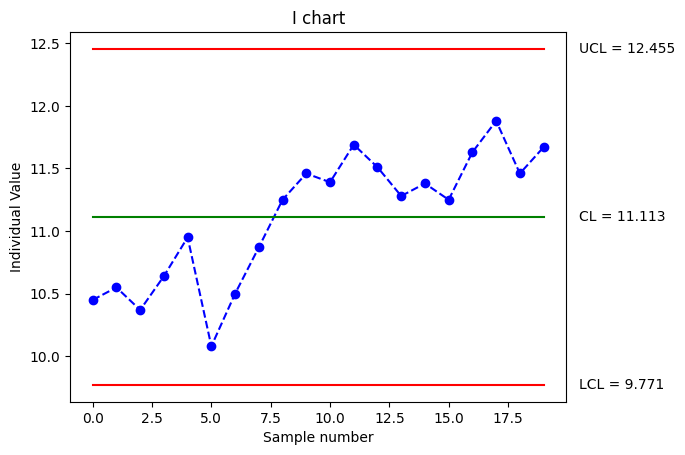

In [35]:
import qdatoolkit as qda
import numpy as np
import matplotlib.pyplot as plt
data_I = qda.ControlCharts.I(data, 'X')
# qda toolkit doesn't support known variance
n = 5
sigma = 1
sigma_xbar = sigma/np.sqrt(n)
xbarbar = data['X'].mean()
data_I = data.copy()
data_I.rename(columns={'X':'I'}, inplace=True)
data_I['I_UCL'] = xbarbar + 3*sigma_xbar
data_I['I_CL'] = xbarbar
data_I['I_LCL'] = xbarbar - 3*sigma_xbar

def plot_I_chart( df ):
    # Plot the I chart
    plt.title('I chart')
    plt.plot(df['I'], color='b', linestyle='--', marker='o')
    plt.plot(df['I_UCL'], color='r')
    plt.plot(df['I_CL'], color='g')
    plt.plot(df['I_LCL'], color='r')
    plt.ylabel('Individual Value')
    plt.xlabel('Sample number')
    plt.text(len(df)+.5, df['I_UCL'].iloc[0], 'UCL = {:.3f}'.format(df['I_UCL'].iloc[0]), verticalalignment='center')
    plt.text(len(df)+.5, df['I_CL'].iloc[0], 'CL = {:.3f}'.format(df['I_CL'].iloc[0]), verticalalignment='center')
    plt.text(len(df)+.5, df['I_LCL'].iloc[0], 'LCL = {:.3f}'.format(df['I_LCL'].iloc[0]), verticalalignment='center')
    plt.show()

plot_I_chart(data_I)

## CUMSUM

Parameters: $ h = 4 $ and $ k = 0.5 $
- $ H = h \cdot \sigma_{\bar{x}} $
- $ K = k \cdot \sigma_{\bar{x}} $

Remember:
- $ C_i^+ = \max(0, \bar{x}_i - (\mu_0 + K) + C_{i-1}^+) $
- $ C_i^- = \max(0, (\mu_0 - K) - \bar{x}_i + C_{i-1}^-) $

The data 'X' is an individual. But for example this individual can be the mean of n samples. (extracted from sample_mean of Xbar chart df)

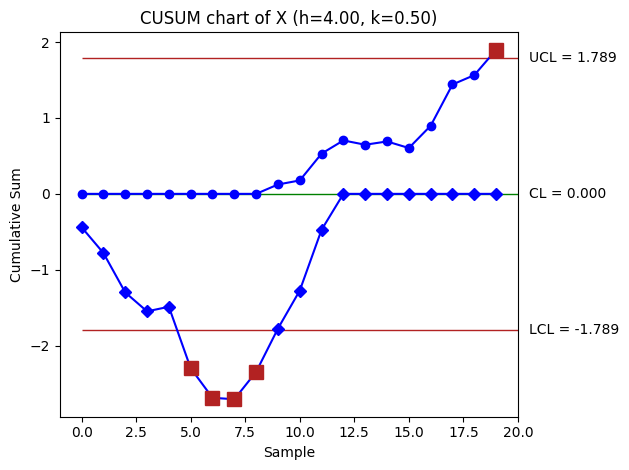

In [42]:
h = 4
k = 0.5
sigma_xbar = sigma/np.sqrt(n)
xbarbar = data['X'].mean()
H = h*sigma_xbar # upper CL
K = k*sigma_xbar
data_CUSUM = qda.ControlCharts.CUSUM(data, 'X', params=(h,k), mean = xbarbar, sigma_xbar = sigma_xbar)

The new estimated process mean is calculated by the following formula:
$$\hat{\mu} = \mu_0 + K + \frac{C_i^+}{N_h} $$

Where:
- $N_h$ is the number of the upper cumulator of consecutive non-zero values before the OOC is detected.

In [46]:
# Create a time series Nh that is 0 when Ci+ is 0 and increases by 1 for every consecutive Ci+ > 0
Nh = pd.Series(0, index=data_CUSUM.index)
counter = 0
for idx in data_CUSUM.index:
    if data_CUSUM.loc[idx, 'Ci+'] > 0:
        # If Ci+ is positive, increment the counter
        counter += 1
        Nh[idx] = counter
    else:
        # If Ci+ is 0, reset the counter to 0
        counter = 0
        Nh[idx] = 0
# Add Nh+ column to the CUSUM dataframe
data_CUSUM['Nh+'] = Nh

first_out_of_control = data_CUSUM[data_CUSUM['Ci+'] > H].index[0]
print('The first out of control point is at index:', first_out_of_control)
Nh = data_CUSUM['Nh+'].iloc[first_out_of_control]
print('N_h = {}'.format(Nh))
print('K = {}'.format(K))
# Get the cusum value at the first OOC sample
print('C+_i = {}'.format(data_CUSUM['Ci+'].iloc[first_out_of_control]))

# Calculate the estimated mean
mu_hat = mu + K + data_CUSUM['Ci+'].iloc[first_out_of_control] / Nh
print('mu_hat = {}'.format(mu_hat))

The first out of control point is at index: 19
N_h = 11
K = 0.22360679774997896
C+_i = 1.8973252247502472
mu_hat = 24.396090909090912


## EWMA

param. $ \lambda = 0.2 $

Remember:
- $ z_0 = \bar{\bar{x}} = 11.113 $
- $ z_i = \lambda \cdot \bar{x}_i + (1 - \lambda) \cdot z_{i-1} $
- $ a_t = \frac{\lambda}{2-\lambda} \cdot [1 - (1 - \lambda)^{2t}] $

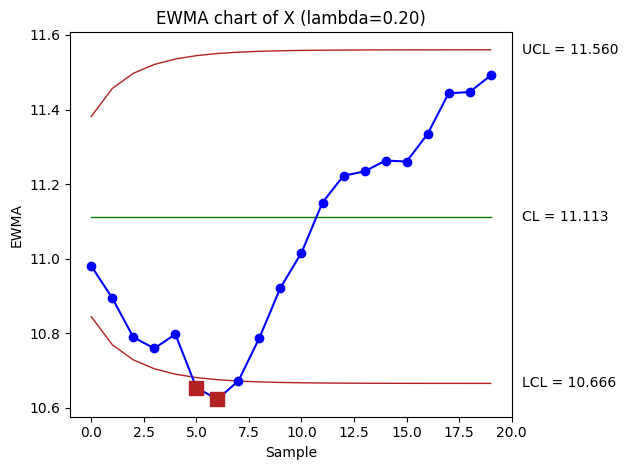

In [21]:
lambda_ = 0.2
sigma_xbar = sigma/np.sqrt(n)
xbarbar = data['X'].mean()
df_EWMA = qda.ControlCharts.EWMA(data, 'X', lambda_, xbarbar, sigma_xbar)

## p-chart

These are control charts for attributes. P chart is for proportions.

In [ ]:
df = pd.DataFrame({
    "Unanswered Calls": [5, 8, 13, 11, 8, 6, 5, 3, 1, 6, 4, 12, 6, 8, 13, 17, 4, 5, 4, 9, 7, 2, 3, 6],
    "Total Calls": [100, 120, 150, 130, 110, 100, 90, 80, 70, 100, 90, 140, 100, 110, 150, 180, 90, 100, 80, 120, 110, 70, 80, 100]
})
df["p"] = df["Unanswered Calls"] / df["Total Calls"]

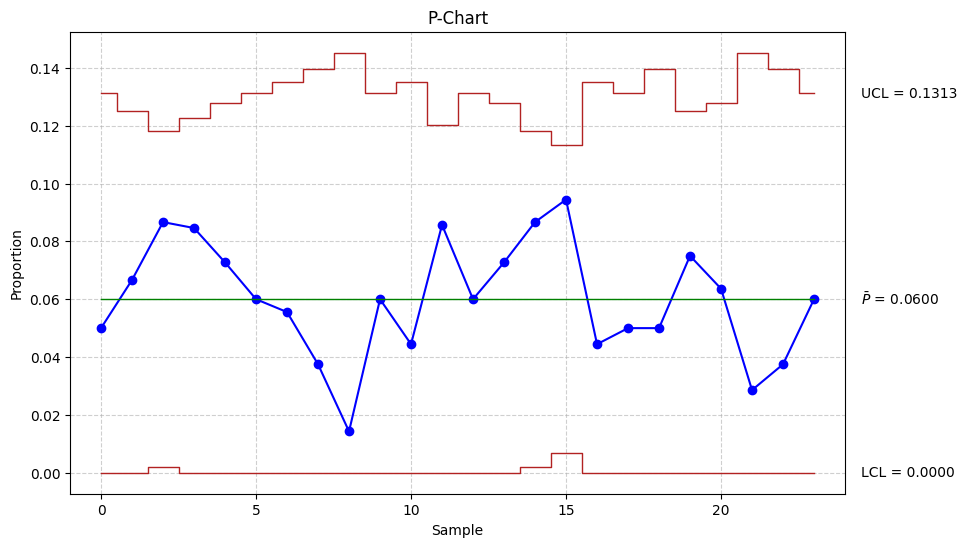

In [ ]:
p_bar = df["p"].mean()

# UCL, LCL, CL
df["std_dev"] = np.sqrt((p_bar * (1 - p_bar)) / df["Total Calls"])
df['P_CL'] = p_bar  # Center Line (CL) for the p-chart
df["P_UCL"] = df['P_CL'] + 3 * df["std_dev"]
df["P_LCL"] = df['P_CL'] - 3 * df["std_dev"]
df["P_LCL"] = df["P_LCL"].clip(lower=0)  # LCL cannot be <0

# Plot p-Chart
plt.figure(figsize=(10, 6))
plt.plot(df["p"], marker='o', color='blue', label='Proporzione osservata')
plt.step(df.index, df["P_CL"], where='mid', color='g', linestyle='-', linewidth=1)
plt.step(df.index, df["P_UCL"], where='mid', color='firebrick', linestyle='-', linewidth=1)
plt.step(df.index, df["P_LCL"], where='mid', color='firebrick', linestyle='-', linewidth=1)
plt.xlabel('Sample')
plt.ylabel('Proportion')
plt.title('P-Chart')
# add the values of the control limits on the right side of the plot
plt.text(len(df)+.5, df['P_UCL'].iloc[0], 'UCL = {:.4f}'.format(df['P_UCL'].iloc[-1]), verticalalignment='center')
plt.text(len(df)+.5, p_bar, r'$\bar{P}$' + ' = {:.4f}'.format(p_bar), verticalalignment='center')
plt.text(len(df)+.5, df['P_LCL'].iloc[0], 'LCL = {:.4f}'.format(df['P_LCL'].iloc[-1]), verticalalignment='center')
plt.grid(True, linestyle='--', alpha=0.6)
# set the x-axis limits
plt.xlim(-1, len(df))
plt.show()

## np-chart

The engineer tests 500 light bulbs each hour and records the defectives.

In [54]:
df = pd.DataFrame({
    "Subgroup ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124],
    "Defectives": [5, 8, 13, 11, 8, 6, 5, 3, 1, 6, 4, 12, 6, 8, 13, 17, 4, 5, 4, 9, 7, 2, 3, 6]
})
n = 500

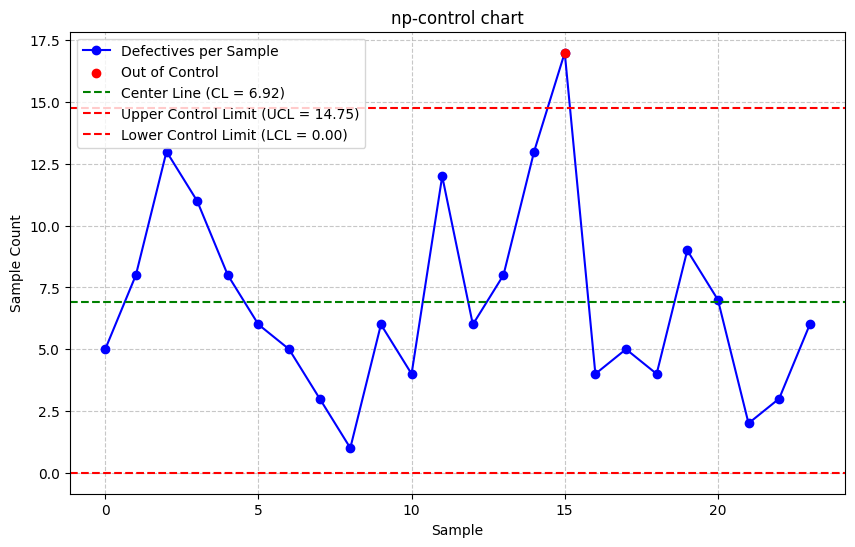

In [55]:
p_hat = df['Defectives'].mean() / n

center_line = n * p_hat
UCL = center_line + 3 * np.sqrt(n * p_hat * (1 - p_hat))
LCL = max(0, center_line - 3 * np.sqrt(n * p_hat * (1 - p_hat)))

out_of_control = df[(df['Defectives'] > UCL) | (df['Defectives'] < LCL)]
plt.figure(figsize=(10, 6))
plt.plot(df['Defectives'], marker='o', linestyle='-', color='blue', label='Defectives per Sample')
plt.scatter(out_of_control.index, out_of_control['Defectives'], color='red', zorder=5, label='Out of Control')
plt.axhline(center_line, color='green', linestyle='--', linewidth=1.5, label=f'Center Line (CL = {center_line:.2f})')
plt.axhline(UCL, color='red', linestyle='--', linewidth=1.5, label=f'Upper Control Limit (UCL = {UCL:.2f})')
plt.axhline(LCL, color='red', linestyle='--', linewidth=1.5, label=f'Lower Control Limit (LCL = {LCL:.2f})')

plt.title('np-control chart')
plt.xlabel('Sample')
plt.ylabel('Sample Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## c-chart

Every hour, the engineer takes an equal lenght sample of wallpaper and counts the number of defects.

In [56]:
data = pd.DataFrame({
    'Sample ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'Defects': [24, 28, 36, 47, 23, 26, 29, 45, 48, 32, 45, 56, 58, 41, 25, 38, 21, 29, 38, 32, 45, 42, 26, 38, 45]
})

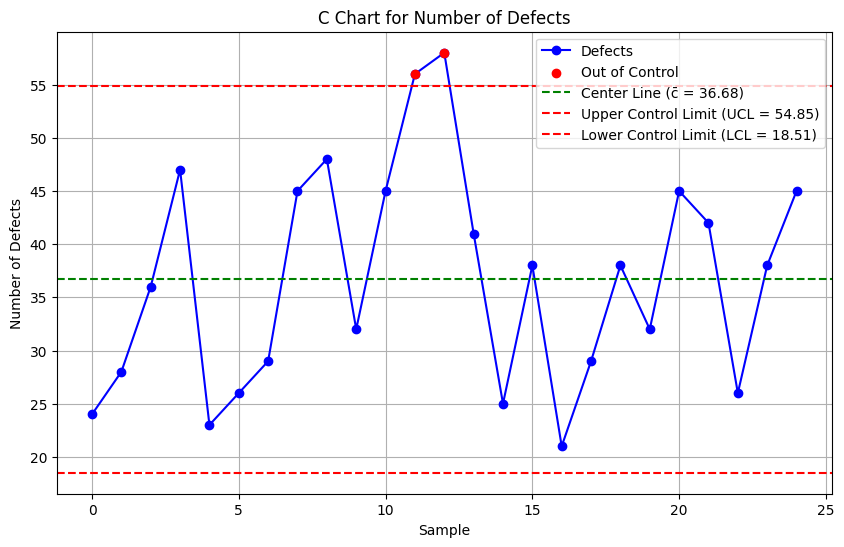

In [57]:
c_bar = data['Defects'].mean()

# Calculate control limits
UCL = c_bar + 3 * np.sqrt(c_bar)
LCL = max(0, c_bar - 3 * np.sqrt(c_bar))

# Plot the C chart
plt.figure(figsize=(10, 6))
plt.plot(data['Defects'], marker='o', linestyle='-', color='b', label='Defects')

# Highlight points outside control limits
out_of_control = data[(data['Defects'] > UCL) | (data['Defects'] < LCL)]
plt.scatter(out_of_control.index, out_of_control['Defects'], color='red', zorder=5, label='Out of Control')

# Plot control lines
plt.axhline(y=c_bar, color='g', linestyle='--', label=f'Center Line (c̄ = {c_bar:.2f})')
plt.axhline(y=UCL, color='r', linestyle='--', label=f'Upper Control Limit (UCL = {UCL:.2f})')
plt.axhline(y=LCL, color='r', linestyle='--', label=f'Lower Control Limit (LCL = {LCL:.2f})')

# Add titles and labels
plt.title('C Chart for Number of Defects')
plt.xlabel('Sample')
plt.ylabel('Number of Defects')
plt.legend()
plt.grid(True)
plt.show()

## u-chart

selects 25 sets of pages (Each set has a different number of pages) from consecutive orders and counts the number of typographical errors (defects)

In [58]:
data = pd.DataFrame({
    'Number of Pages': [30, 24, 23, 25, 32, 30, 24, 30, 27, 24, 30, 32, 26, 31, 24, 27, 27, 30, 32, 24, 26, 32, 30, 24, 25],
    'Errors': [3, 4, 2, 6, 5, 18, 6, 5, 10, 4, 4, 7, 5, 8, 5, 7, 4, 17, 5, 8, 6, 8, 9, 5, 3]
})
data['Errors_per_Page'] = (data['Errors'] / data['Number of Pages'])

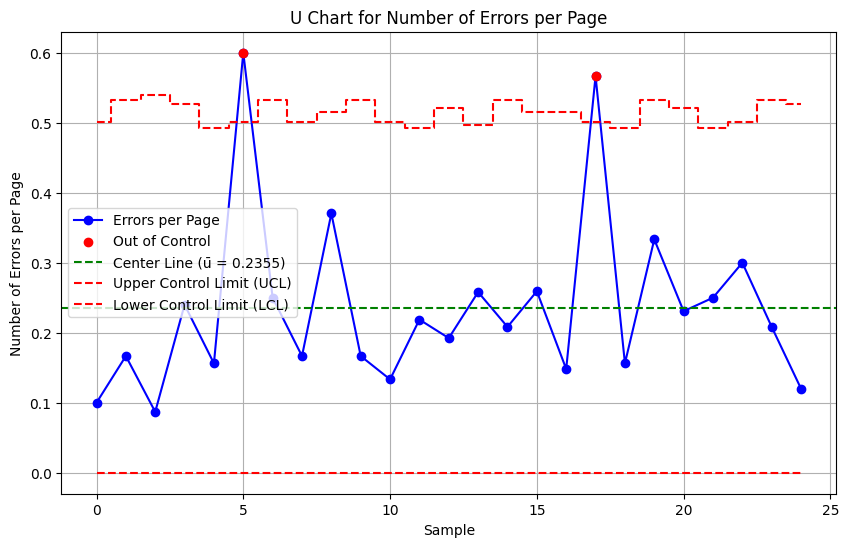

In [59]:
u_bar = data['Errors_per_Page'].mean()

# Calculate control limits
L = 3  # Typically, L = 3
UCL = u_bar + L * np.sqrt(u_bar / data['Number of Pages'])
LCL = u_bar - L * np.sqrt(u_bar / data['Number of Pages'])
LCL[LCL < 0] = 0  # Lower control limit cannot be negative

# Plot the U chart
plt.figure(figsize=(10, 6))
plt.plot(data['Errors_per_Page'], marker='o', linestyle='-', color='b', label='Errors per Page')

# Highlight points outside control limits
out_of_control = data[(data['Errors_per_Page'] > UCL) | (data['Errors_per_Page'] < LCL)]
plt.scatter(out_of_control.index, out_of_control['Errors_per_Page'], color='red', zorder=5, label='Out of Control')

# Plot control lines
plt.axhline(y=u_bar, color='g', linestyle='--', label=f'Center Line (ū = {u_bar:.4f})')
plt.step(data.index, UCL, where='mid', color='r', linestyle='--', label='Upper Control Limit (UCL)')
plt.step(data.index, LCL, where='mid', color='r', linestyle='--', label='Lower Control Limit (LCL)')

# Add titles and labels
plt.title('U Chart for Number of Errors per Page')
plt.xlabel('Sample')
plt.ylabel('Number of Errors per Page')
plt.legend()
plt.grid(True)
plt.show()